# Lecture 12 Tutorial: Continuous-Discrete EKF for Truck Tracking

## Learning Objectives
In this tutorial, you will:
- Implement a **Continuous-Discrete Extended Kalman Filter (CD-EKF)** using the `estimation` package.
- Understand how to handle **nonlinear measurement models** (radar range).
- See how **state augmentation** can estimate an unknown sensor bias.
- Use **RK4 numerical integration** for continuous-time state and covariance propagation.
- Visualize filter convergence and the role of covariance bounds.

## Problem Statement

![kf_image](kf_tutorial.png)

### Simulation parameters:
Accelerometer bias 0.01 $m/s^2$

Accelerometer noise standard deviation 0.001 $m/s^2$

Ranging noise standard deviation 1 $m$

Process noise standard deviation 0.5 $m/s^2$

### Vehicle Dynamics model
$$
\begin{bmatrix}\dot{x}\\ \dot{v}\end{bmatrix} = \begin{bmatrix}0 & 1\\ 0 & 0\end{bmatrix}\begin{bmatrix}x\\ v\end{bmatrix} + \begin{bmatrix}0 \\ a_{true}(t)\end{bmatrix} + \begin{bmatrix}0 \\ \omega(t)\end{bmatrix}
$$

### Acceleration measurement model
$$
a_{meas}(t) = a_{true} + b + \omega_a(t)
$$

### Measurement model
Range from the $i^{th}$ station
$$
r_i(k) = \sqrt{(x_i - x)^2 + h_i^2} + \nu(k)
$$
where $x_i, h_i$ are the position and the height of the $i^{th}$ radar. The position and altitude of each radar are provided in the table below

|         | x       | h     |
|---------|---------|-------|
| radar 1 | -1000 m | 500 m |
| radar 2 | 3000 m  | 500 m |
| radar 3 | 4000 m  | 500 m |

The truck accelerates from $0~m/s^2$ to $0.05~m/s^2$ in first $100~s$, remains at $0.05~m/s^2$ acceleration for next $100~s$ and deccelerates to $0~m/s^2$ in the next $100~s$.

Simulate the measured acceleration and the measured ranges based on the above specifications for 300s at every 1 second.
Develop an EKF estimator to estimate the position, velocity and the accelerometer bias. Show the performance of the implemented EKF using proper figures with error, standard deviations and residuals.

## Theory Recap

### Augmented State Vector
The truck state is augmented with the unknown accelerometer bias $b$:
$$
X = \begin{bmatrix} x \\ v \\ b \end{bmatrix}
$$

### Continuous Dynamics (Estimator)
The bias-corrected dynamics used by the estimator are:
$$
\dot{X} = \begin{bmatrix} 0 & 1 & 0 \\ 0 & 0 & -1 \\ 0 & 0 & 0 \end{bmatrix} X + \begin{bmatrix} 0 \\ a_{meas} \\ 0 \end{bmatrix}
$$
The state Jacobian is:
$$
A = \frac{\partial f}{\partial X} = \begin{bmatrix} 0 & 1 & 0 \\ 0 & 0 & -1 \\ 0 & 0 & 0 \end{bmatrix}
$$

### Discrete Measurements (Radar Range)
Three radars at known positions $(x_i, h_i)$ measure range:
$$
r_i = \sqrt{(x_i - x)^2 + h_i^2} + \nu_i
$$
The measurement Jacobian for the $i$-th radar is:
$$
C_i = \frac{\partial r_i}{\partial X} = \begin{bmatrix} \frac{-(x_i - x)}{r_i} & 0 & 0 \end{bmatrix}
$$

### CD-EKF Algorithm
- **Prediction (Continuous):** Integrate $\dot{\hat{X}} = f(\hat{X}, u)$ and  $\dot{P} = AP + PA^T + GQG^T$ between measurements using RK4.
- **Update (Discrete):** Standard EKF update with the nonlinear $h(\hat{X})$ and Jacobian $C_k$, using the Joseph form for $P^+$.

### Why RK4?
The Continuous-Discrete EKF propagates the state and covariance using continuous-time ODEs. We use a 4th-order Runge-Kutta (RK4) integrator for accuracy, which is far superior to a simple Euler step for the same step size.

## Step 0: Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../src')))
import estimation as kf
import importlib
importlib.reload(kf)

np.random.seed(42)


## Step 1: Define System Parameters

We set up all the physical and noise parameters for the simulation. These values match the problem statement exactly.

In [2]:
# --- Simulation Parameters ---
T_total = 300.0       # Total simulation time [s]
dt_meas = 1.0         # Measurement interval [s]
dt_int  = 0.01        # Integration time step for continuous dynamics [s]

# Number of integration steps per measurement interval
n_int_steps = int(dt_meas / dt_int)

# Total number of measurement epochs
N_meas = int(T_total / dt_meas)

# --- True System Parameters ---
b_true = 0.01         # True accelerometer bias [m/s^2]

# --- Noise Parameters ---
sigma_a     = 0.001   # Accelerometer noise std [m/s^2]
sigma_proc  = 0.5     # Process noise std [m/s^2]
sigma_b     = 0.001   # Bias random walk std [m/s^2 / sqrt(s)]
sigma_r     = 1.0     # Ranging noise std [m]

# Process noise spectral density matrix (continuous)
# G maps process noise into the state derivative
G = np.array([[0.0, 0.0],
              [1.0, 0.0],
              [0.0, 1.0]])

Q_c = np.diag([sigma_proc**2, sigma_b**2])  # Continuous spectral density

# Measurement noise covariance (3 radars)
R = sigma_r**2 * np.eye(3)

# --- Radar Sensor Positions ---
radars = np.array([[-1000.0, 500.0],   # Radar 1: (x_i, h_i)
                    [ 3000.0, 500.0],   # Radar 2
                    [ 4000.0, 500.0]])  # Radar 3

print("Radar positions (x_i, h_i):")
for i, (xi, hi) in enumerate(radars):
    print(f"  Radar {i+1}: x = {xi:7.0f} m, h = {hi:.0f} m")

Radar positions (x_i, h_i):
  Radar 1: x =   -1000 m, h = 500 m
  Radar 2: x =    3000 m, h = 500 m
  Radar 3: x =    4000 m, h = 500 m


## Step 2: Generate the True Acceleration Profile

The truck accelerates from $0$ to $0.05~m/s^2$ in the first $100~s$, holds $0.05~m/s^2$ for the next $100~s$, and decelerates to $0~m/s^2$ in the last $100~s$.

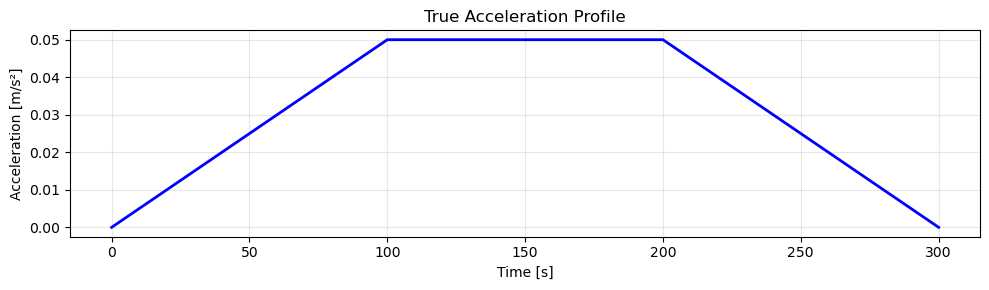

In [3]:
def true_acceleration(t):
    """Returns the true acceleration at time t [s]."""
    if t < 100.0:
        return 0.05 * (t / 100.0)           # Ramp up
    elif t < 200.0:
        return 0.05                          # Constant
    elif t < 300.0:
        return 0.05 * (1.0 - (t - 200.0) / 100.0)  # Ramp down
    else:
        return 0.0

# Plot the acceleration profile
t_plot = np.linspace(0, T_total, 1000)
a_plot = [true_acceleration(t) for t in t_plot]
plt.figure(figsize=(10, 3))
plt.plot(t_plot, a_plot, 'b-', linewidth=2)
plt.xlabel('Time [s]')
plt.ylabel('Acceleration [m/s²]')
plt.title('True Acceleration Profile')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 3: Simulate the True Trajectory and Measurements

We propagate the true state using Euler-Maruyama integration and generate noisy accelerometer and radar range measurements.

In [4]:
# Total integration steps
N_steps = int(T_total / dt_int)
t_sim = np.linspace(0, T_total, N_steps + 1)

# True state history: [x, v, b]
x_true_hist = np.zeros((3, N_steps + 1))
x_true_hist[:, 0] = [0.0, 0.0, b_true]  # Start at origin, zero velocity

for k in range(N_steps):
    x_k, v_k, b_k = x_true_hist[:, k]
    a_true_k = true_acceleration(t_sim[k])
    # Process noise
    w_a = sigma_proc * np.sqrt(dt_int) * np.random.randn()
    w_b = sigma_b * np.sqrt(dt_int) * np.random.randn()
    # Euler-Maruyama integration
    x_true_hist[0, k+1] = x_k + v_k * dt_int
    x_true_hist[1, k+1] = v_k + a_true_k * dt_int + w_a
    x_true_hist[2, k+1] = b_k + w_b  # Bias random walk

# --- Accelerometer readings at each integration step ---
a_meas_hist = np.array([true_acceleration(t_sim[k]) for k in range(N_steps + 1)]) + \
              x_true_hist[2, :] + sigma_a * np.random.randn(N_steps + 1)

# --- Radar range measurements at discrete measurement times ---
def range_measurement(x_pos, radar):
    """Compute true range from truck position to radar."""
    return np.sqrt((radar[0] - x_pos)**2 + radar[1]**2)

meas_indices = list(range(0, N_steps + 1, n_int_steps))  # indices into t_sim
meas_times = [t_sim[k] for k in meas_indices]
meas_values = []

for k in meas_indices:
    x_pos = x_true_hist[0, k]
    z_k = np.array([range_measurement(x_pos, r) + sigma_r * np.random.randn()
                    for r in radars])
    meas_values.append(z_k)

print(f"Simulation: {N_steps} integration steps, {len(meas_indices)} measurements")
print(f"Final true position: {x_true_hist[0, -1]:.1f} m")
print(f"Final true velocity: {x_true_hist[1, -1]:.1f} m/s")
print(f"Final true bias:     {x_true_hist[2, -1]:.4f} m/s²")

Simulation: 30000 integration steps, 301 measurements
Final true position: 1972.9 m
Final true velocity: 18.0 m/s
Final true bias:     -0.0064 m/s²


### True vs Measured Acceleration

The plot below overlays the true acceleration profile with the noisy accelerometer readings. Notice the offset caused by the accelerometer bias $b$ and the measurement noise $\omega_a(t)$.

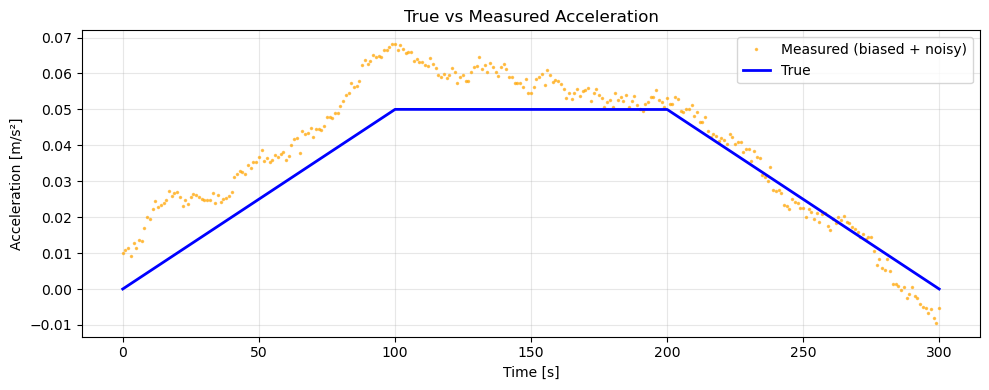

In [5]:
# True acceleration at each simulation time step
a_true_hist = np.array([true_acceleration(t) for t in t_sim])

# Down-sample for plotting (every 100th point to avoid clutter)
step = 100
plt.figure(figsize=(10, 4))
plt.plot(t_sim[::step], a_meas_hist[::step], '.', color='orange',
         markersize=3, alpha=0.6, label='Measured (biased + noisy)')
plt.plot(t_sim, a_true_hist, 'b-', linewidth=2, label='True')
plt.xlabel('Time [s]')
plt.ylabel('Acceleration [m/s²]')
plt.title('True vs Measured Acceleration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4: Implement the EKF Model Class

Now it is your turn! You need to define a single model class that the `estimation.ExtendedKalmanFilter` will use. The class needs to have the following callable methods:
- `dynamics(X, t)`: State continuous-time ODE.
- `Phi(X, t)`: Jacobian of dynamics w.r.t. state.
- `h(X)`: Predicted measurement function.
- `H(X)`: Jacobian of observation function.

Note: The covariance dynamics ODE is handled internally by the filter! The `a_meas` reading must be passed inside the model to calculate dynamics.

In [6]:
class TruckModel:
    def __init__(self, radars, a_meas_k=0.0):
        self.radars = radars
        self.a_meas_k = a_meas_k
        
    def dynamics(self, X, t):
        x, v, b = X
        # dx/dt = v; dv/dt = a_meas_k - b; db/dt = 0
        return np.array([v, self.a_meas_k - b, 0.0])
        
    def Phi(self, X, t):
        # State Jacobian A
        return np.array([[0.0, 1.0,  0.0],
                         [0.0, 0.0, -1.0],
                         [0.0, 0.0,  0.0]])
                         
    def h(self, X):
        # Predicted range measurements: h(X)
        x = X[0]
        return np.array([np.sqrt((r[0] - x)**2 + r[1]**2) for r in self.radars])
        
    def H(self, X):
        # Measurement Jacobian C = dh/dX
        x = X[0]
        n_radars = self.radars.shape[0]
        C = np.zeros((n_radars, 3))
        for i, r in enumerate(self.radars):
            ri = np.sqrt((r[0] - x)**2 + r[1]**2)
            C[i, 0] = -(r[0] - x) / ri
        return C

## Step 5: Run the CD-EKF Filter Loop

Now wire everything together. Use `kf.ExtendedKalmanFilter` from the `estimation` package.

The filter loop works as follows:
1. At each measurement epoch, **predict** by propagating the state and covariance forward using RK4.
2. After prediction, **correct** using the radar range measurement.
3. Store the estimated state and covariance diagonals for plotting.

**Important:** The state dynamics need the measured acceleration at each integration step. Update `model.a_meas_k` before calling `predict()`.

In [7]:
# --- Initialization ---
state0 = kf.State(x=np.array([0.0, 0.0, 0.0]), 
                  P=np.diag([100.0**2, 10.0**2, 1.0**2]), 
                  t=0.0)

model = TruckModel(radars)
Q = G @ Q_c @ G.T  # Compute continuous Q matrix for EKF
ekf = kf.ExtendedKalmanFilter(model, Q, R, state0, dT=dt_meas)

# --- Storage for plotting ---
est_hist    = np.zeros((3, N_meas + 1))
P_diag_hist = np.zeros((3, N_meas + 1))
res_hist    = []
S_hist      = []

est_hist[:, 0]    = state0.x
P_diag_hist[:, 0] = np.diag(state0.P)

# --- Main Filter Loop ---
for m in range(N_meas):
    # Integration step index for accelerometer reading
    sim_idx = meas_indices[m]
    
    # Update current measured acceleration in the model
    ekf.model.a_meas_k = a_meas_hist[sim_idx]

    # Prediction: propagate state and covariance using internal ODE solver
    ekf.predict()

    # Correction: update with radar range measurements
    ekf.correct(meas_values[m+1])

    # Store results
    est_hist[:, m+1]    = ekf.state_post.x
    P_diag_hist[:, m+1] = np.diag(ekf.state_post.P)
    res_hist.append(ekf.state_post.res)
    S_hist.append(ekf.state_post.innovation_cov)

print("CD-EKF complete.")
print(f"Final estimated position: {est_hist[0, -1]:.1f} m (true: {x_true_hist[0, -1]:.1f} m)")
print(f"Final estimated velocity: {est_hist[1, -1]:.3f} m/s (true: {x_true_hist[1, -1]:.3f} m/s)")
print(f"Final estimated bias:     {est_hist[2, -1]:.4f} m/s² (true: {x_true_hist[2, -1]:.4f} m/s²)")


CD-EKF complete.
Final estimated position: 1972.2 m (true: 1972.9 m)
Final estimated velocity: 16.579 m/s (true: 18.003 m/s)
Final estimated bias:     -0.0173 m/s² (true: -0.0064 m/s²)


## Step 6: Visualisation

We plot key diagnostic views to assess filter performance: estimation errors with $\pm 2\sigma$ bounds for each state, and the normalised innovation residuals.

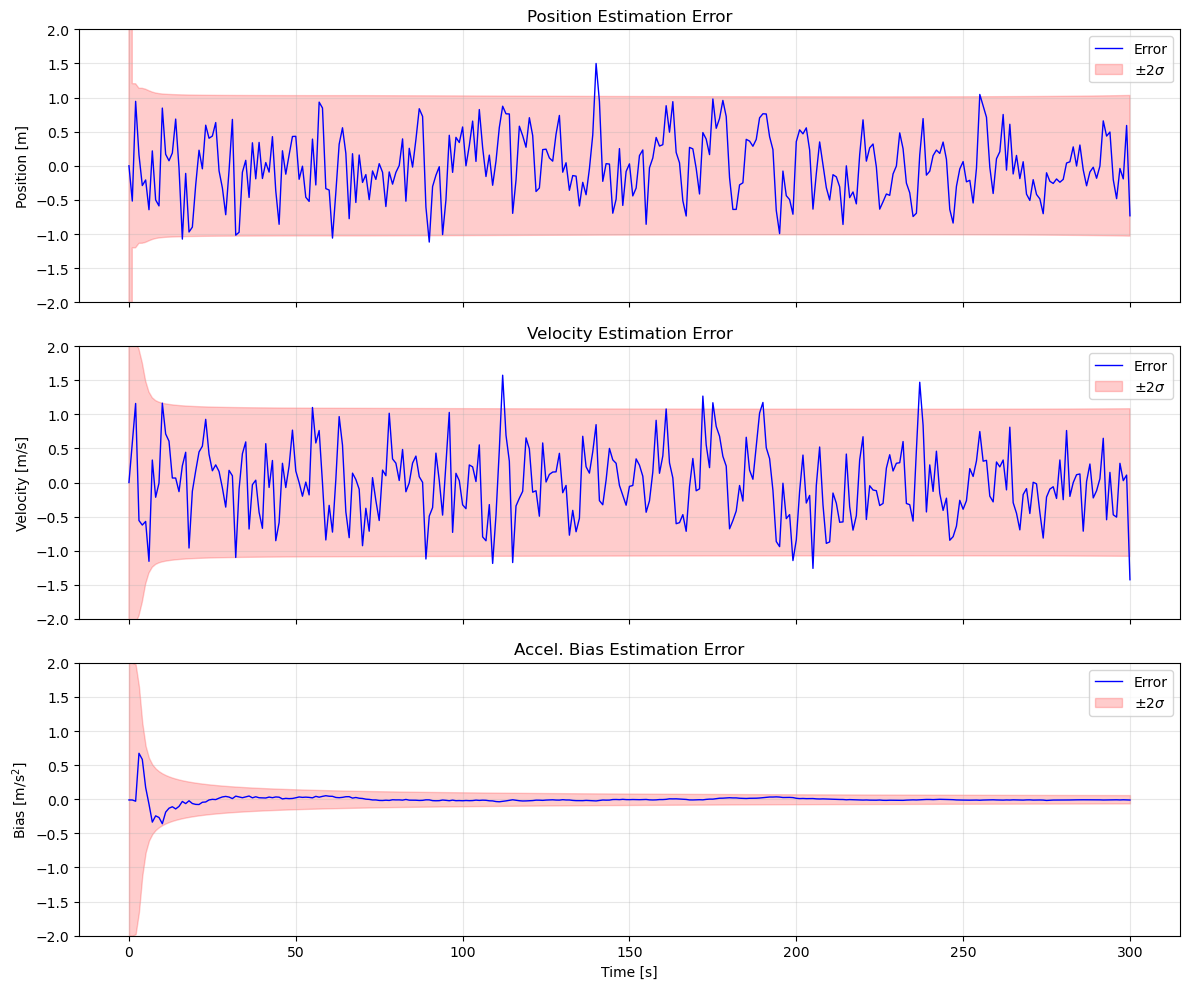

In [8]:
# Measurement-epoch time axis
t_meas = np.array(meas_times)

# True state at measurement epochs
x_true_at_meas = x_true_hist[:, meas_indices]

# Estimation errors
err = est_hist - x_true_at_meas
sigma_bounds = np.sqrt(P_diag_hist)

state_labels = ['Position [m]', 'Velocity [m/s]', r'Bias [m/s$^2$]']
state_names  = ['Position', 'Velocity', 'Accel. Bias']

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t_meas, err[i, :], 'b-', linewidth=1, label='Error')
    ax.fill_between(t_meas,  2*sigma_bounds[i, :], -2*sigma_bounds[i, :],
                    alpha=0.2, color='red', label=r'$\pm 2\sigma$')
    ax.set_ylabel(state_labels[i])
    ax.set_title(f'{state_names[i]} Estimation Error')
    ax.set_ylim(-2, 2)  
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()

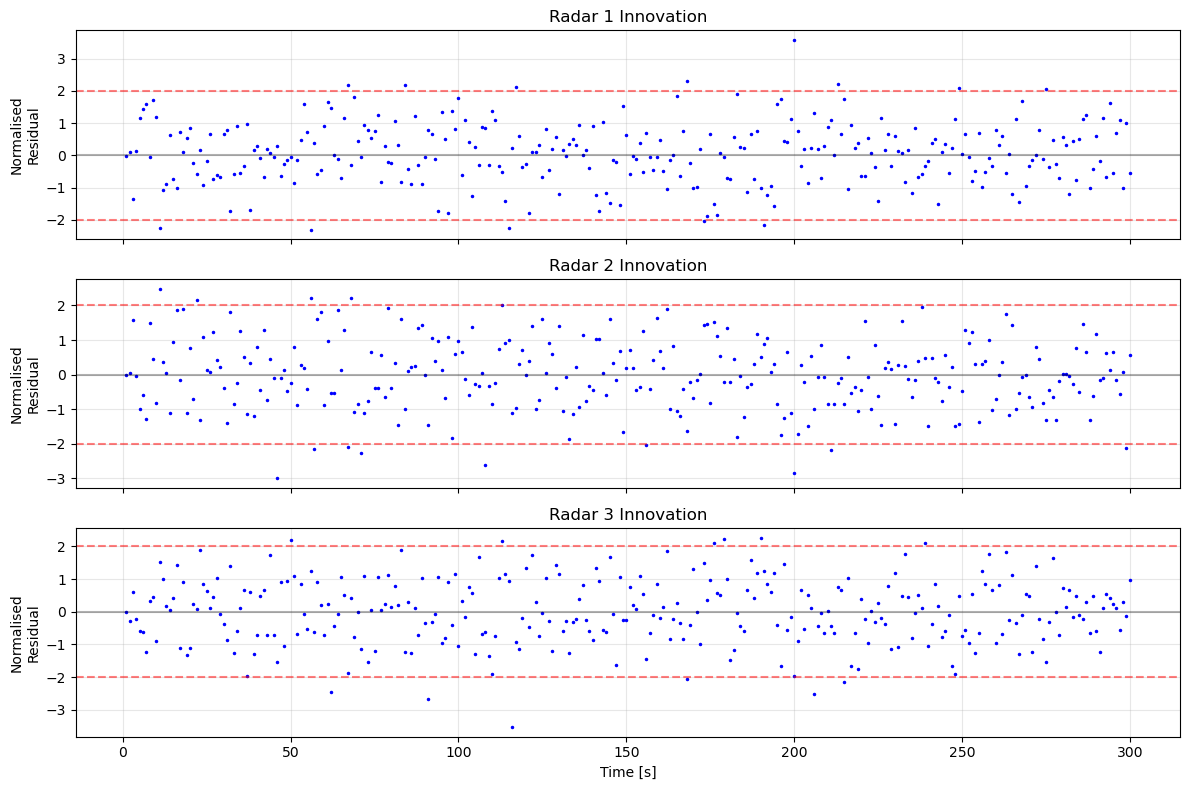

In [9]:
# Normalised Innovation Residuals
if len(res_hist) > 0:
    res_array = np.array(res_hist)   # (N_meas, 3)
    S_array   = np.array(S_hist)     # (N_meas, 3, 3)

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    radar_names = ['Radar 1', 'Radar 2', 'Radar 3']
    for i, ax in enumerate(axes):
        sigma_inn = np.sqrt(S_array[:, i, i])
        normalised = res_array[:, i] / sigma_inn
        ax.plot(t_meas[1:], normalised, 'b.', markersize=3)
        ax.axhline( 2, color='r', linestyle='--', alpha=0.5)
        ax.axhline(-2, color='r', linestyle='--', alpha=0.5)
        ax.axhline( 0, color='k', linestyle='-',  alpha=0.3)
        ax.set_ylabel('Normalised\nResidual')
        ax.set_title(f'{radar_names[i]} Innovation')
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel('Time [s]')
    plt.tight_layout()
    plt.show()

## Student Exercises

Try the following to deepen your understanding:

1. **Increase the ranging noise**: Set `sigma_r = 10 m` and observe how the filter convergence changes. Does the bias still converge?

2. **Remove one radar**: Modify the `radars` array to use only 2 radars. How does this affect observability and convergence?

3. **Change the integration step**: Try `dt_int = 0.1` instead of `0.01`. How does the coarser integration affect filter accuracy? What happens if you use `dt_int = 1.0` (same as measurement interval)?

4. **No bias estimation**: Reduce the state to $[x, v]^T$ (remove bias). Modify the dynamics, Jacobians, and noise matrices accordingly. What happens when the true bias is non-zero but the filter ignores it?